# DAM Project Notebook  
## Expanding the Feature Space for Truthfulness Classification on the LIAR Dataset

This notebook presents an **application-style data mining project** on the **LIAR** fact-checking dataset.  
The main goal is to predict the truthfulness of a political statement and to show, through controlled experiments, how performance changes as we expand the feature space beyond plain text.

## Project objective

The core research question is:

> **How much can truthfulness classification improve when we move from a text-only baseline to a richer feature space that includes metadata, speaker-history signals, and similar-claim retrieval features?**

To answer this, the notebook compares a simple baseline with progressively stronger models and reports both quantitative results and qualitative error analysis.

## Pipeline overview

The project is organized as a step-by-step experimental pipeline:

- **Baseline:** TF-IDF + Multinomial Naive Bayes on the cleaned statement text
- **Improvement 1:** metadata feature engineering
- **Improvement 2:** speaker-history / credibility features
- **Improvement 3:** similar-claim retrieval features using MinHash + LSH
- **Final comparison:** improved linear model vs improved XGBoost model

## Why this project fits the course

This project uses:
- a **real dataset** (`LIAR`)
- methods that are clearly related to course topics in **classification, feature engineering, similarity search / retrieval, and evaluation**
- a structured experimental comparison with **baselines, ablations, plots, and error analysis**

## Important note on scope

The original idea of using **retweet / propagation graphs** is **not compatible** with the LIAR TSV files alone, because LIAR does not provide a social diffusion network.  
Therefore, this notebook focuses on a **reproducible metadata- and retrieval-based extension** of the LIAR task instead of claiming to use unavailable graph data.

## Binary formulation used here

Although LIAR is originally a **six-class** dataset, the main experiments in this notebook use a **binary formulation** to stay aligned with the current project direction:

- **true class**: `true`, `mostly-true`, `half-true`, `barely-true`
- **false class**: `false`, `pants-fire`

An optional six-class sanity-check section is included early in the notebook, but the main comparison table focuses on the binary setup.

## How to run this notebook

Run the notebook **from top to bottom** in order.  
It expects the following files to exist relative to the notebook:

- `data/train.tsv`
- `data/valid.tsv`
- `data/test.tsv`

Outputs such as comparison tables and error-analysis files are written to:

- `data/liar_project_outputs_no_graph/`

## What to look for in the final sections

The most important deliverables inside this notebook are:

- the **consolidated comparison table**
- the **ablation study**
- the **plots comparing models**
- the **error analysis examples**
- the **threshold-tuning analysis**

Together, these sections support the final discussion about what feature groups matter most and where the models still fail.

In [27]:

# Step 0: Imports, configuration, and reproducibility

import os
import re
import math
import random
import hashlib
import warnings
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from scipy import sparse

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
    f1_score,
)
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import SGDClassifier
from sklearn.decomposition import TruncatedSVD

from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 200)

output_dir = "outputs/liar_project_outputs"
plot_dir = os.path.join(output_dir, "figures")
table_dir = os.path.join(output_dir, "tables")

os.makedirs(plot_dir, exist_ok=True)
os.makedirs(table_dir, exist_ok=True)

print("Libraries imported successfully.")


Libraries imported successfully.


# 1. Data Loading

In [2]:

# Step 1: Load the LIAR dataset and construct binary labels

LIAR_COLUMNS = [
    "id",
    "label",
    "statement",
    "subject",
    "speaker",
    "speaker_job_title",
    "state_info",
    "party_affiliation",
    "barely_true_counts",
    "false_counts",
    "half_true_counts",
    "mostly_true_counts",
    "pants_on_fire_counts",
    "context",
]

TRUE_GROUP = {"true", "mostly-true", "half-true", "barely-true"}
FALSE_GROUP = {"false", "pants-fire"}


def read_liar_split(path):
    return pd.read_csv(path, sep="	", header=None, names=LIAR_COLUMNS)


def to_binary_label(label):
    if pd.isna(label):
        return None
    if label in TRUE_GROUP:
        return 1
    if label in FALSE_GROUP:
        return 0
    return None


train_path = "data/train.tsv"
valid_path = "data/valid.tsv"
test_path = "data/test.tsv"

train_df = read_liar_split(train_path)
valid_df = read_liar_split(valid_path)
test_df = read_liar_split(test_path)

for df in [train_df, valid_df, test_df]:
    df["y"] = df["label"].map(to_binary_label)

train_df = train_df.dropna(subset=["y"]).copy()
valid_df = valid_df.dropna(subset=["y"]).copy()
test_df = test_df.dropna(subset=["y"]).copy()

for df in [train_df, valid_df, test_df]:
    df["y"] = df["y"].astype(int)

print("Train shape:", train_df.shape)
print("Valid shape:", valid_df.shape)
print("Test  shape:", test_df.shape)
display(train_df.head())


Train shape: (10240, 15)
Valid shape: (1284, 15)
Test  shape: (1267, 15)


,id,label,statement,subject,speaker,speaker_job_title,state_info,party_affiliation,barely_true_counts,false_counts,half_true_counts,mostly_true_counts,pants_on_fire_counts,context,y
0,2635.json,false,Says the Annies List political group supports ...,abortion,dwayne-bohac,State representative,Texas,republican,0.0,1.0,0.0,0.0,0.0,a mailer,0
1,10540.json,half-true,When did the decline of coal start? It started...,"energy,history,job-accomplishments",scott-surovell,State delegate,Virginia,democrat,0.0,0.0,1.0,1.0,0.0,a floor speech.,1
2,324.json,mostly-true,"Hillary Clinton agrees with John McCain ""by vo...",foreign-policy,barack-obama,President,Illinois,democrat,70.0,71.0,160.0,163.0,9.0,Denver,1
3,1123.json,false,Health care reform legislation is likely to ma...,health-care,blog-posting,NaN,NaN,none,7.0,19.0,3.0,5.0,44.0,a news release,0
4,9028.json,half-true,The economic turnaround started at the end of ...,"economy,jobs",charlie-crist,NaN,Florida,democrat,15.0,9.0,20.0,19.0,2.0,an interview on CNN,1


### Notes on dataset construction

The LIAR splits are loaded from TSV files with a fixed column schema.  
At this stage, the notebook constructs the working target variable and standardizes the text field used by downstream models.

Two label settings appear in the notebook:

- an **optional six-class view** for sanity checking class balance and feasibility
- the **main binary label mapping** used for the core experiments

This separation is useful because the six-class version preserves the original label granularity, while the binary version makes it easier to study whether richer feature engineering improves discrimination between broadly **true-like** and **false-like** claims.

In [3]:

# Step 2: Text cleaning utilities

def clean_text(text):
    text = "" if pd.isna(text) else str(text)
    text = text.lower()
    text = re.sub(r"[^a-z0-9' ]+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

for df in [train_df, valid_df, test_df]:
    df["statement_clean"] = df["statement"].apply(clean_text)

display(train_df[["statement", "statement_clean"]].head())


,statement,statement_clean
0,Says the Annies List political group supports ...,says the annies list political group supports ...
1,When did the decline of coal start? It started...,when did the decline of coal start it started ...
2,"Hillary Clinton agrees with John McCain ""by vo...",hillary clinton agrees with john mccain by vot...
3,Health care reform legislation is likely to ma...,health care reform legislation is likely to ma...
4,The economic turnaround started at the end of ...,the economic turnaround started at the end of ...


## Optional sanity check: six-class baseline

In [4]:

# Step 3: Six-class label mapping and baseline

LABEL_ORDER = ["pants-fire", "false", "barely-true", "half-true", "mostly-true", "true"]
LABEL_TO_INT = {label: i for i, label in enumerate(LABEL_ORDER)}


def to_six_class_label(label):
    if pd.isna(label):
        return None
    return LABEL_TO_INT.get(label, None)

train_df6 = read_liar_split(train_path)
valid_df6 = read_liar_split(valid_path)
test_df6 = read_liar_split(test_path)

for df in [train_df6, valid_df6, test_df6]:
    df["y"] = df["label"].apply(to_six_class_label)
    df["statement_clean"] = df["statement"].apply(clean_text)

train_df6 = train_df6.dropna(subset=["y"]).copy()
valid_df6 = valid_df6.dropna(subset=["y"]).copy()
test_df6 = test_df6.dropna(subset=["y"]).copy()

for df in [train_df6, valid_df6, test_df6]:
    df["y"] = df["y"].astype(int)

y_train6 = train_df6["y"].values
y_test6 = test_df6["y"].values

vectorizer6 = TfidfVectorizer(
    ngram_range=(1, 2), min_df=2, max_features=20000, sublinear_tf=True
)
X_train6 = vectorizer6.fit_transform(train_df6["statement_clean"])
X_test6 = vectorizer6.transform(test_df6["statement_clean"])

nb6 = MultinomialNB(alpha=0.5)
nb6.fit(X_train6, y_train6)
test_pred_nb6 = nb6.predict(X_test6)

print("Six-class NB — Test Report:")
print(classification_report(y_test6, test_pred_nb6, target_names=LABEL_ORDER, digits=4))


Six-class NB — Test Report:
              precision    recall  f1-score   support

  pants-fire     0.0000    0.0000    0.0000        92
       false     0.2597    0.3213    0.2873       249
 barely-true     0.2672    0.1462    0.1890       212
   half-true     0.2169    0.3396    0.2647       265
 mostly-true     0.2397    0.3154    0.2724       241
        true     0.2613    0.1394    0.1818       208

    accuracy                         0.2415      1267
   macro avg     0.2075    0.2103    0.1992      1267
weighted avg     0.2296    0.2415    0.2251      1267



# 2. Quick Exploratory Checks


Train
-----
Rows: 10240
Class counts:
y
0    2834
1    7406
Name: count, dtype: int64

Missing values:
speaker_job_title       2898
state_info              2210
context                  102
subject                    2
speaker                    2
party_affiliation          2
barely_true_counts         2
false_counts               2
half_true_counts           2
mostly_true_counts         2
pants_on_fire_counts       2
dtype: int64

Validation
----------
Rows: 1284
Class counts:
y
0    379
1    905
Name: count, dtype: int64

Missing values:
speaker_job_title    345
state_info           279
context               12
dtype: int64

Test
----
Rows: 1267
Class counts:
y
0    341
1    926
Name: count, dtype: int64

Missing values:
speaker_job_title    325
state_info           262
context               17
dtype: int64


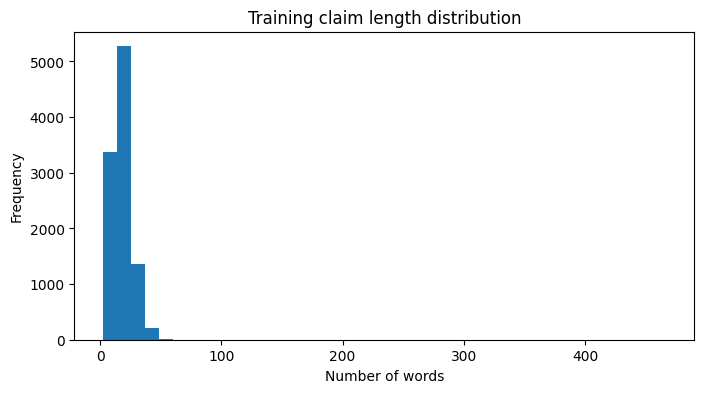

In [5]:

# Step 4: Basic exploratory analysis

def summarize_split(df, name):
    print(f"\n{name}")
    print("-" * len(name))
    print("Rows:", len(df))
    print("Class counts:")
    print(df["y"].value_counts().sort_index())
    print("\nMissing values:")
    missing = df.isna().sum()
    print(missing[missing > 0].sort_values(ascending=False))

summarize_split(train_df, "Train")
summarize_split(valid_df, "Validation")
summarize_split(test_df, "Test")

for df in [train_df, valid_df, test_df]:
    df["statement_len_words_raw"] = df["statement"].fillna("").str.split().apply(len)

plt.figure(figsize=(8, 4))
plt.hist(train_df["statement_len_words_raw"], bins=40)
plt.title("Training claim length distribution")
plt.xlabel("Number of words")
plt.ylabel("Frequency")
plt.show()


# 3. Evaluation Helpers

In [6]:

# Step 5: Common evaluation helpers

y_train = train_df["y"].values
y_valid = valid_df["y"].values
y_test = test_df["y"].values


def evaluate_predictions(y_true, y_pred, y_prob=None, split_name="Split"):
    acc = accuracy_score(y_true, y_pred)
    precision_bin, recall_bin, f1_bin, _ = precision_recall_fscore_support(
        y_true, y_pred, average="binary", zero_division=0
    )
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    precision_by_class, recall_by_class, f1_by_class, support_by_class = precision_recall_fscore_support(
        y_true, y_pred, labels=[0, 1], average=None, zero_division=0
    )

    metrics = {
        "accuracy": acc,
        "binary_precision": precision_bin,
        "binary_recall": recall_bin,
        "binary_f1": f1_bin,
        "macro_precision": precision_macro,
        "macro_recall": recall_macro,
        "macro_f1": f1_macro,
        "false_recall": recall_by_class[0],
        "true_recall": recall_by_class[1],
    }

    if y_prob is not None:
        metrics["auc_roc"] = roc_auc_score(y_true, y_prob)

    print(f"{split_name} Accuracy      : {metrics['accuracy']:.4f}")
    print(f"{split_name} Binary-F1     : {metrics['binary_f1']:.4f}")
    print(f"{split_name} Macro-F1      : {metrics['macro_f1']:.4f}")
    print(f"{split_name} False Recall  : {metrics['false_recall']:.4f}")
    print(f"{split_name} True Recall   : {metrics['true_recall']:.4f}")
    if y_prob is not None:
        print(f"{split_name} AUC-ROC       : {metrics['auc_roc']:.4f}")

    return metrics


def make_results_row(model_name, valid_metrics, test_metrics):
    row = {
        "model": model_name,
        "valid_accuracy": valid_metrics["accuracy"],
        "valid_binary_f1": valid_metrics["binary_f1"],
        "valid_macro_f1": valid_metrics["macro_f1"],
        "test_accuracy": test_metrics["accuracy"],
        "test_binary_f1": test_metrics["binary_f1"],
        "test_macro_f1": test_metrics["macro_f1"],
        "test_false_recall": test_metrics["false_recall"],
    }
    if "auc_roc" in test_metrics:
        row["test_auc_roc"] = test_metrics["auc_roc"]
    return row


# 4. Baseline: TF-IDF + Multinomial Naive Bayes

We begin with a text-only baseline built from the cleaned claim statement. Each claim is represented by unigram and bigram TF-IDF features, and a Multinomial Naive Bayes classifier is trained on that sparse representation.

## 4.1 Model Formulation

Let a document be represented by a vector $x = (x_1, x_2, \dots, x_V)$, where $x_j$ denotes the weight of term $j$ and $V$ is the vocabulary size. Under the multinomial Naive Bayes model, where $w_j$ represents the j-th word/term in the vocabulary:

$$
P(x \mid y) = \prod_{j=1}^{V} P(w_j \mid y)^{x_j}.
$$

By Bayes' rule,

$$
P(y \mid x) = \frac{P(y)\,P(x \mid y)}{P(x)}.
$$

Since $P(x)$ does not depend on the class label, the prediction rule can be written as

$$
\hat{y} = \arg\max_{y} P(y)\,P(x \mid y).
$$

Taking logarithms gives the additive decision function

$$
\hat{y} = \arg\max_{y} \left( \log P(y) + \sum_{j=1}^{V} x_j \log P(w_j \mid y) \right).
$$

This additive form is attractive for high-dimensional sparse text because each term contributes independently to the final class score.

## 4.2 Role of the Baseline

The baseline serves as the text-only reference point for the rest of the notebook. It tells us how much predictive signal can be extracted from the wording of the claim alone, before any metadata, retrieval-based, or graph-derived information is introduced.

The conditional independence assumption is clearly simplified for natural language, since words in a sentence are not truly independent. Even so, the model remains useful here because it is efficient, reproducible, and often competitive on sparse bag-of-words representations. More importantly, it provides a clear reference for evaluating how much the later feature-space expansions improve the task.

Baseline performance
Validation Accuracy      : 0.7126
Validation Binary-F1     : 0.8281
Validation Macro-F1      : 0.4758
Validation False Recall  : 0.0686
Validation True Recall   : 0.9823
Validation AUC-ROC       : 0.6504
Test Accuracy      : 0.7301
Test Binary-F1     : 0.8417
Test Macro-F1      : 0.4636
Test False Recall  : 0.0469
Test True Recall   : 0.9816
Test AUC-ROC       : 0.6591

Classification report on test:
              precision    recall  f1-score   support

           0     0.4848    0.0469    0.0856       341
           1     0.7366    0.9816    0.8417       926

    accuracy                         0.7301      1267
   macro avg     0.6107    0.5143    0.4636      1267
weighted avg     0.6689    0.7301    0.6382      1267



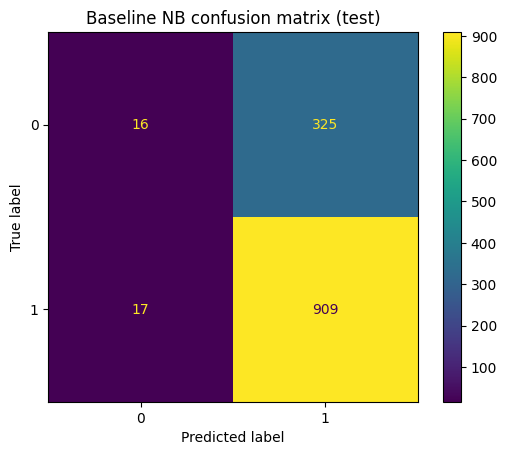

In [7]:

# Step 6: Baseline model - TF-IDF + Multinomial Naive Bayes

baseline_vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    max_features=20000,
    sublinear_tf=True,
)

X_train_text = baseline_vectorizer.fit_transform(train_df["statement_clean"])
X_valid_text = baseline_vectorizer.transform(valid_df["statement_clean"])
X_test_text = baseline_vectorizer.transform(test_df["statement_clean"])

baseline_nb = MultinomialNB(alpha=0.5)
baseline_nb.fit(X_train_text, y_train)

valid_pred_nb = baseline_nb.predict(X_valid_text)
test_pred_nb = baseline_nb.predict(X_test_text)
prob_valid_nb = baseline_nb.predict_proba(X_valid_text)[:, 1]
prob_nb = baseline_nb.predict_proba(X_test_text)[:, 1]

print("Baseline performance")
baseline_valid_metrics = evaluate_predictions(y_valid, valid_pred_nb, prob_valid_nb, "Validation")
baseline_test_metrics = evaluate_predictions(y_test, test_pred_nb, prob_nb, "Test")

print("\nClassification report on test:")
print(classification_report(y_test, test_pred_nb, digits=4))

ConfusionMatrixDisplay.from_predictions(y_test, test_pred_nb)
plt.title("Baseline NB confusion matrix (test)")
plt.show()


# 5. Improvement 1: Metadata Feature Engineering

The first major feature-space expansion introduces information that is already present in LIAR, but not yet expressed in a form that a classifier can use directly and effectively.

## 5.1 Feature Construction

We use the following categorical metadata fields:
- `subject`
- `speaker`
- `speaker_job_title`
- `state_info`
- `party_affiliation`
- `context`

After cleaning missing values and grouping rare categories, these fields are encoded with one-hot encoding.

In addition, the dataset provides five speaker-history count fields:
- `barely_true_counts`
- `false_counts`
- `half_true_counts`
- `mostly_true_counts`
- `pants_on_fire_counts`

From these raw counts, we derive aggregate and ratio-based features such as:
- total historical fact-check count,
- false-oriented ratio,
- true-oriented ratio,
- extreme-false ratio,
- smoothed credibility-style scores,
- claim length in words.

## 5.2 Why These Features Matter

A claim is not determined by wording alone. The same topic may be associated with different reliability patterns across speakers, contexts, and affiliations. Similarly, the raw count history of a speaker can be transformed into prior evidence about how that speaker has been evaluated in earlier fact-checks.

The important point is that the improvement lies in the **engineered representation**, not merely in the existence of the raw columns. The notebook converts categorical, numeric, and historical information into a structured feature space that can be combined with the text representation.

## 5.3 Expected Effect

These features are intended to address a limitation of the baseline: a text-only model may miss useful context when two claims are lexically similar but come from very different speakers or political settings. Metadata and speaker-history features help the model distinguish such cases more effectively.

In [8]:

# Step 7: Metadata and speaker-history preprocessing helpers

CATEGORICAL_COLS = [
    "subject",
    "speaker",
    "speaker_job_title",
    "state_info",
    "party_affiliation",
    "context",
]

HISTORY_COLS = [
    "barely_true_counts",
    "false_counts",
    "half_true_counts",
    "mostly_true_counts",
    "pants_on_fire_counts",
]


def _clean_categorical_series(s):
    return (
        s.fillna("UNKNOWN")
         .astype(str)
         .str.strip()
         .replace("", "UNKNOWN")
    )


def fit_category_trimmer(df, categorical_cols, min_freq=3):
    keep_values = {}
    for col in categorical_cols:
        values = _clean_categorical_series(df[col])
        counts = values.value_counts()
        keep_values[col] = set(counts[counts >= min_freq].index)
        keep_values[col].add("UNKNOWN")
    return keep_values


def apply_category_trimmer(df, keep_values, categorical_cols, history_cols):
    df = df.copy()
    for col in categorical_cols:
        values = _clean_categorical_series(df[col])
        allowed = keep_values[col]
        df[col] = values.where(values.isin(allowed), "OTHER")

    for col in history_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0.0)

    return df


def add_metadata_features(df):
    df = df.copy()
    df["statement_len_words"] = df["statement"].fillna("").str.split().apply(len)
    df["statement_len_chars"] = df["statement"].fillna("").astype(str).str.len()
    df["subject_count"] = df["subject"].fillna("").apply(
        lambda x: len([s.strip() for s in str(x).split(",") if s.strip()])
    )
    df["has_job_title"] = df["speaker_job_title"].notna().astype(int)
    df["has_state_info"] = df["state_info"].notna().astype(int)
    df["has_context"] = df["context"].notna().astype(int)
    df["is_major_party"] = df["party_affiliation"].fillna("").str.lower().isin(["democrat", "republican"]).astype(int)
    df["num_exclamation_marks"] = df["statement"].fillna("").astype(str).str.count("!")
    return df


def add_history_features(df, alpha=1.0):
    df = df.copy()

    b = df["barely_true_counts"].astype(float)
    f = df["false_counts"].astype(float)
    h = df["half_true_counts"].astype(float)
    m = df["mostly_true_counts"].astype(float)
    p = df["pants_on_fire_counts"].astype(float)

    total = b + f + h + m + p

    df["history_total"] = total
    df["false_ratio"] = (f + p) / np.where(total > 0, total, 1.0)
    df["trueish_ratio"] = (b + h + m) / np.where(total > 0, total, 1.0)
    df["extreme_false_ratio"] = p / np.where(total > 0, total, 1.0)
    df["credibility_smoothed"] = (b + h + m + alpha) / (total + 2 * alpha)
    df["history_balance"] = ((b + h + m) - (f + p)) / np.where(total > 0, total, 1.0)

    return df


METADATA_NUMERIC_COLS = [
    "statement_len_words",
    "statement_len_chars",
    "subject_count",
    "has_job_title",
    "has_state_info",
    "has_context",
    "is_major_party",
    "num_exclamation_marks",
]

SPEAKER_HISTORY_NUMERIC_COLS = HISTORY_COLS + [
    "history_total",
    "false_ratio",
    "trueish_ratio",
    "extreme_false_ratio",
    "credibility_smoothed",
    "history_balance",
]


In [9]:

# Step 8: Fit trimming rules on TRAIN only and build metadata tables

category_keep_values = fit_category_trimmer(
    train_df,
    categorical_cols=CATEGORICAL_COLS,
    min_freq=3,
)

train_meta = apply_category_trimmer(train_df, category_keep_values, CATEGORICAL_COLS, HISTORY_COLS)
valid_meta = apply_category_trimmer(valid_df, category_keep_values, CATEGORICAL_COLS, HISTORY_COLS)
test_meta = apply_category_trimmer(test_df, category_keep_values, CATEGORICAL_COLS, HISTORY_COLS)

train_meta = add_metadata_features(train_meta)
valid_meta = add_metadata_features(valid_meta)
test_meta = add_metadata_features(test_meta)

train_meta_history = add_history_features(train_meta)
valid_meta_history = add_history_features(valid_meta)
test_meta_history = add_history_features(test_meta)

print("Metadata numeric columns:", METADATA_NUMERIC_COLS)
print("Speaker-history numeric columns:", SPEAKER_HISTORY_NUMERIC_COLS)
display(train_meta_history.head())


Metadata numeric columns: ['statement_len_words', 'statement_len_chars', 'subject_count', 'has_job_title', 'has_state_info', 'has_context', 'is_major_party', 'num_exclamation_marks']
Speaker-history numeric columns: ['barely_true_counts', 'false_counts', 'half_true_counts', 'mostly_true_counts', 'pants_on_fire_counts', 'history_total', 'false_ratio', 'trueish_ratio', 'extreme_false_ratio', 'credibility_smoothed', 'history_balance']


,id,label,statement,subject,speaker,speaker_job_title,state_info,party_affiliation,barely_true_counts,false_counts,half_true_counts,mostly_true_counts,pants_on_fire_counts,context,y,statement_clean,statement_len_words_raw,statement_len_words,statement_len_chars,subject_count,has_job_title,has_state_info,has_context,is_major_party,num_exclamation_marks,history_total,false_ratio,trueish_ratio,extreme_false_ratio,credibility_smoothed,history_balance
0,2635.json,false,Says the Annies List political group supports ...,abortion,OTHER,State representative,Texas,republican,0.0,1.0,0.0,0.0,0.0,a mailer,0,says the annies list political group supports ...,11,11,82,1,1,1,1,1,0,1.0,1.000000,0.000000,0.000000,0.333333,-1.000000
1,10540.json,half-true,When did the decline of coal start? It started...,OTHER,OTHER,State delegate,Virginia,democrat,0.0,0.0,1.0,1.0,0.0,a floor speech.,1,when did the decline of coal start it started ...,24,24,141,1,1,1,1,1,0,2.0,0.000000,1.000000,0.000000,0.750000,1.000000
2,324.json,mostly-true,"Hillary Clinton agrees with John McCain ""by vo...",foreign-policy,barack-obama,President,Illinois,democrat,70.0,71.0,160.0,163.0,9.0,Denver,1,hillary clinton agrees with john mccain by vot...,19,19,105,1,1,1,1,1,0,473.0,0.169133,0.830867,0.019027,0.829474,0.661734
3,1123.json,false,Health care reform legislation is likely to ma...,health-care,blog-posting,UNKNOWN,UNKNOWN,none,7.0,19.0,3.0,5.0,44.0,a news release,0,health care reform legislation is likely to ma...,12,12,78,1,1,1,1,0,0,78.0,0.807692,0.192308,0.564103,0.200000,-0.615385
4,9028.json,half-true,The economic turnaround started at the end of ...,"economy,jobs",charlie-crist,UNKNOWN,Florida,democrat,15.0,9.0,20.0,19.0,2.0,an interview on CNN,1,the economic turnaround started at the end of ...,10,10,54,2,1,1,1,1,0,65.0,0.169231,0.830769,0.030769,0.820896,0.661538


In [10]:

# Step 9: Metadata-only linear model

preprocessor_metadata = ColumnTransformer(
    transformers=[
        (
            "text",
            TfidfVectorizer(
                ngram_range=(1, 2),
                min_df=2,
                max_features=20000,
                sublinear_tf=True,
            ),
            "statement_clean",
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            CATEGORICAL_COLS,
        ),
        (
            "num_metadata",
            StandardScaler(with_mean=False),
            METADATA_NUMERIC_COLS,
        ),
    ],
    remainder="drop",
)

metadata_linear_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocessor_metadata),
        (
            "model",
            SGDClassifier(
                loss="log_loss",
                alpha=1e-5,
                max_iter=2000,
                tol=1e-4,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

metadata_linear_pipeline.fit(train_meta, y_train)

valid_pred_metadata = metadata_linear_pipeline.predict(valid_meta)
test_pred_metadata = metadata_linear_pipeline.predict(test_meta)
prob_valid_metadata = metadata_linear_pipeline.predict_proba(valid_meta)[:, 1]
prob_metadata = metadata_linear_pipeline.predict_proba(test_meta)[:, 1]

print("Metadata-only linear model performance")
metadata_valid_metrics = evaluate_predictions(y_valid, valid_pred_metadata, prob_valid_metadata, "Validation")
metadata_test_metrics = evaluate_predictions(y_test, test_pred_metadata, prob_metadata, "Test")


Metadata-only linear model performance
Validation Accuracy      : 0.6768
Validation Binary-F1     : 0.7942
Validation Macro-F1      : 0.5205
Validation False Recall  : 0.1794
Validation True Recall   : 0.8851
Validation AUC-ROC       : 0.5880
Test Accuracy      : 0.6898
Test Binary-F1     : 0.8065
Test Macro-F1      : 0.5126
Test False Recall  : 0.1613
Test True Recall   : 0.8844
Test AUC-ROC       : 0.5742


# 6. Improvement 2: Speaker-History / Credibility Features

In [11]:

# Step 10: Metadata + speaker-history linear model

NUMERIC_METADATA_HISTORY_COLS = METADATA_NUMERIC_COLS + SPEAKER_HISTORY_NUMERIC_COLS

preprocessor_history = ColumnTransformer(
    transformers=[
        (
            "text",
            TfidfVectorizer(
                ngram_range=(1, 2),
                min_df=2,
                max_features=20000,
                sublinear_tf=True,
            ),
            "statement_clean",
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            CATEGORICAL_COLS,
        ),
        (
            "num_metadata_history",
            StandardScaler(with_mean=False),
            NUMERIC_METADATA_HISTORY_COLS,
        ),
    ],
    remainder="drop",
)

history_linear_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocessor_history),
        (
            "model",
            SGDClassifier(
                loss="log_loss",
                alpha=1e-5,
                max_iter=2000,
                tol=1e-4,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

history_linear_pipeline.fit(train_meta_history, y_train)

valid_pred_history = history_linear_pipeline.predict(valid_meta_history)
test_pred_history = history_linear_pipeline.predict(test_meta_history)
prob_valid_history = history_linear_pipeline.predict_proba(valid_meta_history)[:, 1]
prob_history = history_linear_pipeline.predict_proba(test_meta_history)[:, 1]

print("Metadata + speaker-history linear model performance")
history_valid_metrics = evaluate_predictions(y_valid, valid_pred_history, prob_valid_history, "Validation")
history_test_metrics = evaluate_predictions(y_test, test_pred_history, prob_history, "Test")


Metadata + speaker-history linear model performance
Validation Accuracy      : 0.7780
Validation Binary-F1     : 0.8459
Validation Macro-F1      : 0.7247
Validation False Recall  : 0.5726
Validation True Recall   : 0.8641
Validation AUC-ROC       : 0.8253
Test Accuracy      : 0.7774
Test Binary-F1     : 0.8505
Test Macro-F1      : 0.7076
Test False Recall  : 0.5367
Test True Recall   : 0.8661
Test AUC-ROC       : 0.8009


# 7. Improvement 3: Similar-Claim Retrieval Features Using MinHash + LSH

This section adds retrieval-based features so that each claim can benefit from information about similar claims in the training set.

## 7.1 Motivation

Many claims in political fact-checking data are repeated, paraphrased, or slightly reworded versions of earlier talking points. A purely supervised text classifier treats each example independently, even though a new claim may be closely related to previously seen statements.

To capture this local neighborhood structure, we retrieve similar claims and summarize their relationship to the current claim as numerical features.

## 7.2 Jaccard Similarity

Each cleaned claim is represented as a set of word shingles. Given two claims represented by sets $A$ and $B$, their Jaccard similarity is

$$
J(A,B) = \frac{|A \cap B|}{|A \cup B|}.
$$

This measure is well suited to duplicate and near-duplicate detection because it evaluates overlap relative to total size.

## 7.3 MinHash

Directly comparing all claim pairs with Jaccard similarity is expensive. MinHash provides an efficient approximation. For a random permutation $\pi$, the MinHash value of a set $S$ is

$$
h_\pi(S) = \min(\pi(S)).
$$

A key property is

$$
\Pr[h_\pi(A) = h_\pi(B)] = J(A,B).
$$

This means that collision frequency under random hashing reflects set similarity. By using multiple hash functions, each claim receives a compact signature that approximates its similarity relationships.

## 7.4 Locality Sensitive Hashing

The signatures are further organized with Locality Sensitive Hashing. Instead of comparing every signature with every other signature, LSH places signature bands into buckets and only treats bucket collisions as candidate neighbors. This reduces the amount of pairwise comparison while preserving likely similar pairs.

## 7.5 Derived Retrieval Features

The retrieved neighbors are not used to assign labels directly. Instead, they are summarized into claim-level features such as:
- number of candidate neighbors,
- maximum Jaccard similarity,
- mean similarity among the top matches,
- fraction of matched neighbors that belong to the positive class.

These summaries are then appended to the rest of the feature space. In this way, the classifier benefits from similar-claim evidence without leaving the supervised classification setting.

In [12]:

# Step 11: MinHash + LSH utilities

LARGE_PRIME = 4294967311


def stable_token_hash(token):
    return int(hashlib.md5(token.encode("utf-8")).hexdigest(), 16) % LARGE_PRIME


def make_word_shingles(text, k=3):
    words = text.split()
    if len(words) < k:
        return set(words) if words else {"<EMPTY>"}
    return {" ".join(words[i:i+k]) for i in range(len(words) - k + 1)}


def generate_hash_params(num_perm, seed=RANDOM_STATE):
    rng = np.random.default_rng(seed)
    a = rng.integers(1, LARGE_PRIME - 1, size=num_perm, dtype=np.int64)
    b = rng.integers(0, LARGE_PRIME - 1, size=num_perm, dtype=np.int64)
    return a, b


HASH_A, HASH_B = generate_hash_params(num_perm=64)


def minhash_signature(shingle_set, hash_a=HASH_A, hash_b=HASH_B):
    if not shingle_set:
        shingle_set = {"<EMPTY>"}
    tokens = np.array([stable_token_hash(t) for t in shingle_set], dtype=np.int64)
    sig = np.full(len(hash_a), LARGE_PRIME, dtype=np.int64)
    for token_hash in tokens:
        values = (hash_a * token_hash + hash_b) % LARGE_PRIME
        sig = np.minimum(sig, values)
    return sig


def build_lsh_index(signatures, bands=8, rows_per_band=8):
    assert bands * rows_per_band == signatures.shape[1]
    buckets = defaultdict(list)
    for idx, sig in enumerate(signatures):
        for band in range(bands):
            start = band * rows_per_band
            end = start + rows_per_band
            band_tuple = tuple(sig[start:end].tolist())
            buckets[(band, band_tuple)].append(idx)
    return buckets


def candidate_indices(query_sig, buckets, bands=8, rows_per_band=8):
    cands = set()
    for band in range(bands):
        start = band * rows_per_band
        end = start + rows_per_band
        band_tuple = tuple(query_sig[start:end].tolist())
        cands.update(buckets.get((band, band_tuple), []))
    return cands


def jaccard_similarity(set_a, set_b):
    denom = len(set_a | set_b)
    if denom == 0:
        return 0.0
    return len(set_a & set_b) / denom


In [13]:

# Step 12: Build MinHash signatures and derive retrieval features

def prepare_shingles(df, shingle_k=3):
    return [make_word_shingles(text, k=shingle_k) for text in df["statement_clean"]]


train_shingles = prepare_shingles(train_meta_history, shingle_k=3)
valid_shingles = prepare_shingles(valid_meta_history, shingle_k=3)
test_shingles = prepare_shingles(test_meta_history, shingle_k=3)

train_signatures = np.vstack([minhash_signature(s) for s in train_shingles])
valid_signatures = np.vstack([minhash_signature(s) for s in valid_shingles])
test_signatures = np.vstack([minhash_signature(s) for s in test_shingles])

lsh_buckets = build_lsh_index(train_signatures, bands=8, rows_per_band=8)


def neighbor_features_for_query(
    query_shingles,
    query_sig,
    buckets,
    reference_shingles,
    reference_labels,
    exclude_index=None,
    top_k=5,
):
    cands = candidate_indices(query_sig, buckets, bands=8, rows_per_band=8)

    if exclude_index is not None and exclude_index in cands:
        cands.remove(exclude_index)

    if not cands:
        return {
            "lsh_candidate_count": 0.0,
            "lsh_max_jaccard": 0.0,
            "lsh_mean_topk_jaccard": 0.0,
            "lsh_topk_true_rate": 0.5,
            "lsh_topk_label_std": 0.0,
        }

    sims = []
    for idx in cands:
        sim = jaccard_similarity(query_shingles, reference_shingles[idx])
        if sim > 0:
            sims.append((idx, sim))

    if not sims:
        return {
            "lsh_candidate_count": float(len(cands)),
            "lsh_max_jaccard": 0.0,
            "lsh_mean_topk_jaccard": 0.0,
            "lsh_topk_true_rate": 0.5,
            "lsh_topk_label_std": 0.0,
        }

    sims.sort(key=lambda x: x[1], reverse=True)
    top = sims[:top_k]
    top_sims = [s for _, s in top]
    top_labels = [reference_labels[idx] for idx, _ in top]

    return {
        "lsh_candidate_count": float(len(cands)),
        "lsh_max_jaccard": float(max(top_sims)),
        "lsh_mean_topk_jaccard": float(np.mean(top_sims)),
        "lsh_topk_true_rate": float(np.mean(top_labels)),
        "lsh_topk_label_std": float(np.std(top_labels)),
    }


train_lsh_features = []
for i in range(len(train_meta_history)):
    train_lsh_features.append(
        neighbor_features_for_query(
            query_shingles=train_shingles[i],
            query_sig=train_signatures[i],
            buckets=lsh_buckets,
            reference_shingles=train_shingles,
            reference_labels=y_train,
            exclude_index=i,
            top_k=5,
        )
    )

valid_lsh_features = []
for i in range(len(valid_meta_history)):
    valid_lsh_features.append(
        neighbor_features_for_query(
            query_shingles=valid_shingles[i],
            query_sig=valid_signatures[i],
            buckets=lsh_buckets,
            reference_shingles=train_shingles,
            reference_labels=y_train,
            exclude_index=None,
            top_k=5,
        )
    )


test_lsh_features = []
for i in range(len(test_meta_history)):
    test_lsh_features.append(
        neighbor_features_for_query(
            query_shingles=test_shingles[i],
            query_sig=test_signatures[i],
            buckets=lsh_buckets,
            reference_shingles=train_shingles,
            reference_labels=y_train,
            exclude_index=None,
            top_k=5,
        )
    )

train_lsh_df = pd.DataFrame(train_lsh_features)
valid_lsh_df = pd.DataFrame(valid_lsh_features)
test_lsh_df = pd.DataFrame(test_lsh_features)

LSH_FEATURE_COLS = list(train_lsh_df.columns)
display(train_lsh_df.head())


,lsh_candidate_count,lsh_max_jaccard,lsh_mean_topk_jaccard,lsh_topk_true_rate,lsh_topk_label_std
0,0.0,0.0,0.0,0.5,0.0
1,0.0,0.0,0.0,0.5,0.0
2,0.0,0.0,0.0,0.5,0.0
3,0.0,0.0,0.0,0.5,0.0
4,0.0,0.0,0.0,0.5,0.0


In [14]:

# Step 13: Merge LSH features into the working tables

train_plus = train_meta_history.reset_index(drop=True).copy()
valid_plus = valid_meta_history.reset_index(drop=True).copy()
test_plus = test_meta_history.reset_index(drop=True).copy()

for col in LSH_FEATURE_COLS:
    train_plus[col] = train_lsh_df[col].values
    valid_plus[col] = valid_lsh_df[col].values
    test_plus[col] = test_lsh_df[col].values

FINAL_NUMERIC_COLS = NUMERIC_METADATA_HISTORY_COLS + LSH_FEATURE_COLS

print("Final numeric feature count:", len(FINAL_NUMERIC_COLS))
display(train_plus[LSH_FEATURE_COLS].describe().T)


Final numeric feature count: 24


,count,mean,std,min,25%,50%,75%,max
lsh_candidate_count,10240.0,0.005664,0.085968,0.0,0.0,0.0,0.0,2.0
lsh_max_jaccard,10240.0,0.004499,0.065466,0.0,0.0,0.0,0.0,1.0
lsh_mean_topk_jaccard,10240.0,0.004499,0.065466,0.0,0.0,0.0,0.0,1.0
lsh_topk_true_rate,10240.0,0.499854,0.033147,0.0,0.5,0.5,0.5,1.0
lsh_topk_label_std,10240.0,0.000195,0.009881,0.0,0.0,0.0,0.0,0.5


# 8. Final Models 

In [15]:

# Step 14: Final improved linear model using text + metadata + history + LSH

preprocessor_final_linear = ColumnTransformer(
    transformers=[
        (
            "text",
            TfidfVectorizer(
                ngram_range=(1, 2),
                min_df=2,
                max_features=25000,
                sublinear_tf=True,
            ),
            "statement_clean",
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            CATEGORICAL_COLS,
        ),
        (
            "num",
            StandardScaler(with_mean=False),
            FINAL_NUMERIC_COLS,
        ),
    ],
    remainder="drop",
)

final_linear_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocessor_final_linear),
        (
            "model",
            SGDClassifier(
                loss="log_loss",
                alpha=5e-6,
                max_iter=2500,
                tol=1e-4,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

final_linear_pipeline.fit(train_plus, y_train)

valid_pred_final_linear = final_linear_pipeline.predict(valid_plus)
test_pred_final_linear = final_linear_pipeline.predict(test_plus)
prob_valid_final_linear = final_linear_pipeline.predict_proba(valid_plus)[:, 1]
prob_final_linear = final_linear_pipeline.predict_proba(test_plus)[:, 1]

print("Final improved linear model performance")
final_linear_valid_metrics = evaluate_predictions(y_valid, valid_pred_final_linear, prob_valid_final_linear, "Validation")
final_linear_test_metrics = evaluate_predictions(y_test, test_pred_final_linear, prob_final_linear, "Test")


Final improved linear model performance
Validation Accuracy      : 0.7819
Validation Binary-F1     : 0.8638
Validation Macro-F1      : 0.6585
Validation False Recall  : 0.3061
Validation True Recall   : 0.9812
Validation AUC-ROC       : 0.8163
Test Accuracy      : 0.7877
Test Binary-F1     : 0.8707
Test Macro-F1      : 0.6385
Test False Recall  : 0.2698
Test True Recall   : 0.9784
Test AUC-ROC       : 0.7991


In [16]:

# Step 15: Final XGBoost model using SVD-compressed features

preprocessor_xgb = ColumnTransformer(
    transformers=[
        (
            "text",
            TfidfVectorizer(
                ngram_range=(1, 2),
                min_df=2,
                max_features=25000,
                sublinear_tf=True,
            ),
            "statement_clean",
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            CATEGORICAL_COLS,
        ),
        (
            "num",
            StandardScaler(with_mean=False),
            FINAL_NUMERIC_COLS,
        ),
    ],
    remainder="drop",
)

X_train_sparse = preprocessor_xgb.fit_transform(train_plus)
X_valid_sparse = preprocessor_xgb.transform(valid_plus)
X_test_sparse = preprocessor_xgb.transform(test_plus)

print("Sparse feature matrix shape (train):", X_train_sparse.shape)

n_components = min(300, X_train_sparse.shape[1] - 1)
svd = TruncatedSVD(n_components=n_components, random_state=RANDOM_STATE)
X_train_dense = svd.fit_transform(X_train_sparse)
X_valid_dense = svd.transform(X_valid_sparse)
X_test_dense = svd.transform(X_test_sparse)

print("Dense SVD feature matrix shape (train):", X_train_dense.shape)
print("Explained variance ratio sum:", svd.explained_variance_ratio_.sum())

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=RANDOM_STATE,
    verbosity=0,
)

xgb_model.fit(X_train_dense, y_train)

prob_valid_xgb = xgb_model.predict_proba(X_valid_dense)[:, 1]
prob_xgb = xgb_model.predict_proba(X_test_dense)[:, 1]
valid_pred_xgb = (prob_valid_xgb >= 0.5).astype(int)
test_pred_xgb = (prob_xgb >= 0.5).astype(int)

print("Final XGBoost model performance")
xgb_valid_metrics = evaluate_predictions(y_valid, valid_pred_xgb, prob_valid_xgb, "Validation")
xgb_test_metrics = evaluate_predictions(y_test, test_pred_xgb, prob_xgb, "Test")


Sparse feature matrix shape (train): (10240, 27065)
Dense SVD feature matrix shape (train): (10240, 300)
Explained variance ratio sum: 0.9341857910063676
Final XGBoost model performance
Validation Accuracy      : 0.8123
Validation Binary-F1     : 0.8758
Validation Macro-F1      : 0.7457
Validation False Recall  : 0.5092
Validation True Recall   : 0.9392
Validation AUC-ROC       : 0.8457
Test Accuracy      : 0.8027
Test Binary-F1     : 0.8730
Test Macro-F1      : 0.7156
Test False Recall  : 0.4633
Test True Recall   : 0.9276
Test AUC-ROC       : 0.8296


## Ablation study on XGBoost

In [17]:

# Step 16: Ablation study with clean feature groups

def run_xgb_ablation(train_data, valid_data, test_data, y_train, y_valid, y_test, exclude_transformers=None, label="Full Model"):
    exclude_transformers = exclude_transformers or []
    transformers = []

    if "text" not in exclude_transformers:
        transformers.append((
            "text",
            TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_features=25000, sublinear_tf=True),
            "statement_clean",
        ))

    if "cat" not in exclude_transformers:
        transformers.append((
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            CATEGORICAL_COLS,
        ))

    if "metadata_num" not in exclude_transformers:
        transformers.append((
            "num_metadata",
            StandardScaler(with_mean=False),
            METADATA_NUMERIC_COLS,
        ))

    if "history_num" not in exclude_transformers:
        transformers.append((
            "num_history",
            StandardScaler(with_mean=False),
            SPEAKER_HISTORY_NUMERIC_COLS,
        ))

    if "lsh" not in exclude_transformers:
        transformers.append((
            "num_lsh",
            StandardScaler(with_mean=False),
            LSH_FEATURE_COLS,
        ))

    preprocessor = ColumnTransformer(transformers=transformers, remainder="drop")

    X_train_sp = preprocessor.fit_transform(train_data)
    X_valid_sp = preprocessor.transform(valid_data)
    X_test_sp = preprocessor.transform(test_data)

    n_components = min(300, X_train_sp.shape[1] - 1)
    svd_ = TruncatedSVD(n_components=n_components, random_state=RANDOM_STATE)
    X_train_d = svd_.fit_transform(X_train_sp)
    X_valid_d = svd_.transform(X_valid_sp)
    X_test_d = svd_.transform(X_test_sp)

    xgb_ = XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        verbosity=0,
    )
    xgb_.fit(X_train_d, y_train)

    test_prob = xgb_.predict_proba(X_test_d)[:, 1]
    test_pred = (test_prob >= 0.5).astype(int)

    metrics = evaluate_predictions(y_test, test_pred, test_prob, split_name=label)
    return {
        "Model": label,
        "Accuracy": round(metrics["accuracy"], 4),
        "Binary-F1": round(metrics["binary_f1"], 4),
        "Macro-F1": round(metrics["macro_f1"], 4),
        "False-Class Recall": round(metrics["false_recall"], 4),
        "AUC-ROC": round(metrics["auc_roc"], 4),
    }


ablation_configs = [
    (None, "Full Model (all retained features)"),
    (["text"], "No Text"),
    (["cat"], "No Metadata Categories"),
    (["metadata_num"], "No Metadata Numeric Features"),
    (["history_num"], "No Speaker-History Features"),
    (["lsh"], "No LSH Features"),
]

ablation_results = []
for exclude, label in ablation_configs:
    result = run_xgb_ablation(
        train_plus,
        valid_plus,
        test_plus,
        y_train,
        y_valid,
        y_test,
        exclude_transformers=exclude,
        label=label,
    )
    ablation_results.append(result)

ablation_df = pd.DataFrame(ablation_results)
display(ablation_df)


Full Model (all retained features) Accuracy      : 0.8027
Full Model (all retained features) Binary-F1     : 0.8730
Full Model (all retained features) Macro-F1      : 0.7156
Full Model (all retained features) False Recall  : 0.4633
Full Model (all retained features) True Recall   : 0.9276
Full Model (all retained features) AUC-ROC       : 0.8296
No Text Accuracy      : 0.7932
No Text Binary-F1     : 0.8663
No Text Macro-F1      : 0.7049
No Text False Recall  : 0.4575
No Text True Recall   : 0.9168
No Text AUC-ROC       : 0.8151
No Metadata Categories Accuracy      : 0.8106
No Metadata Categories Binary-F1     : 0.8780
No Metadata Categories Macro-F1      : 0.7270
No Metadata Categories False Recall  : 0.4780
No Metadata Categories True Recall   : 0.9330
No Metadata Categories AUC-ROC       : 0.8569
No Metadata Numeric Features Accuracy      : 0.7979
No Metadata Numeric Features Binary-F1     : 0.8699
No Metadata Numeric Features Macro-F1      : 0.7088
No Metadata Numeric Features False

,Model,Accuracy,Binary-F1,Macro-F1,False-Class Recall,AUC-ROC
0,Full Model (all retained features),0.8027,0.8730,0.7156,0.4633,0.8296
1,No Text,0.7932,0.8663,0.7049,0.4575,0.8151
2,No Metadata Categories,0.8106,0.8780,0.7270,0.4780,0.8569
3,No Metadata Numeric Features,0.7979,0.8699,0.7088,0.4545,0.8254
4,No Speaker-History Features,0.7348,0.8388,0.5461,0.1672,0.6824
5,No LSH Features,0.7916,0.8649,0.7049,0.4633,0.8226


### How to interpret the comparison table

The comparison table is meant to answer two questions:

1. **Do the added feature groups improve over the text-only baseline?**
2. **Which final modelling choice gives the best trade-off across metrics?**

Besides accuracy, the notebook also reports:

- **Binary F1**, which emphasizes performance on the positive class under the binary setup
- **Macro F1**, which gives a more balanced view across both classes
- **False-class recall**, which is especially useful because fact-checking tasks often suffer when models over-predict the more common or easier class
- **AUC-ROC**, which summarizes ranking quality across thresholds

This matters because a model can look strong on accuracy while still performing poorly on the harder **false** class.

# 9. Consolidated Comparison Table

In [18]:

# Step 17: Consolidated results table

results_df = pd.DataFrame([
    make_results_row("Baseline: TF-IDF + Naive Bayes", baseline_valid_metrics, baseline_test_metrics),
    make_results_row("Improved Linear: text + metadata", metadata_valid_metrics, metadata_test_metrics),
    make_results_row("Improved Linear: text + metadata + history", history_valid_metrics, history_test_metrics),
    make_results_row("Final Linear: text + metadata + history + LSH", final_linear_valid_metrics, final_linear_test_metrics),
    make_results_row("Final XGBoost: text + metadata + history + LSH", xgb_valid_metrics, xgb_test_metrics),
])

results_df = results_df.sort_values(by=["test_macro_f1", "test_auc_roc"], ascending=False).reset_index(drop=True)
display(results_df.round(4))


,model,valid_accuracy,valid_binary_f1,valid_macro_f1,test_accuracy,test_binary_f1,test_macro_f1,test_false_recall,test_auc_roc
0,Final XGBoost: text + metadata + history + LSH,0.8123,0.8758,0.7457,0.8027,0.8730,0.7156,0.4633,0.8296
1,Improved Linear: text + metadata + history,0.7780,0.8459,0.7247,0.7774,0.8505,0.7076,0.5367,0.8009
2,Final Linear: text + metadata + history + LSH,0.7819,0.8638,0.6585,0.7877,0.8707,0.6385,0.2698,0.7991
3,Improved Linear: text + metadata,0.6768,0.7942,0.5205,0.6898,0.8065,0.5126,0.1613,0.5742
4,Baseline: TF-IDF + Naive Bayes,0.7126,0.8281,0.4758,0.7301,0.8417,0.4636,0.0469,0.6591


# 10. Comparative Visualizations

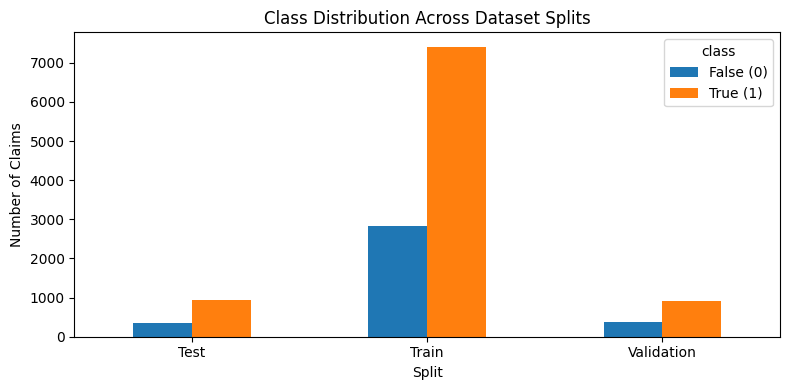

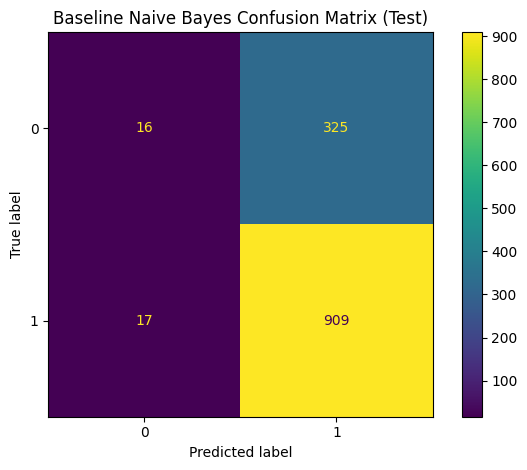

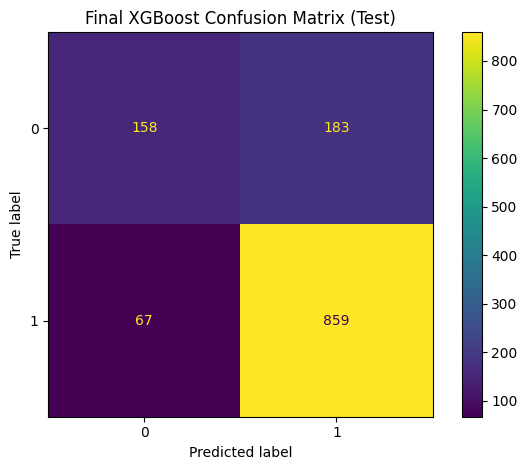

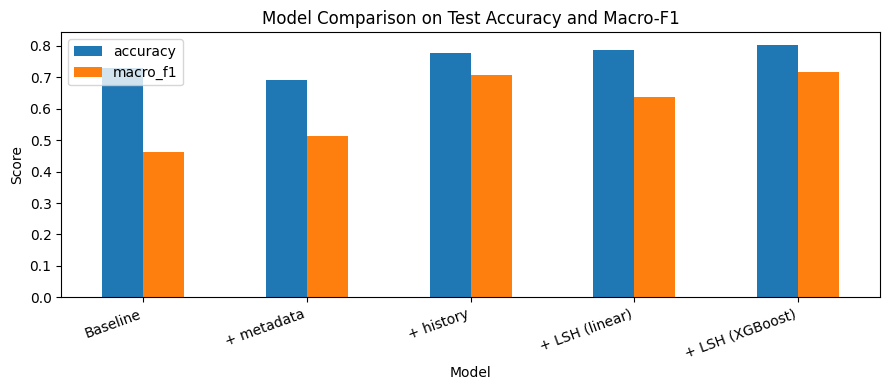

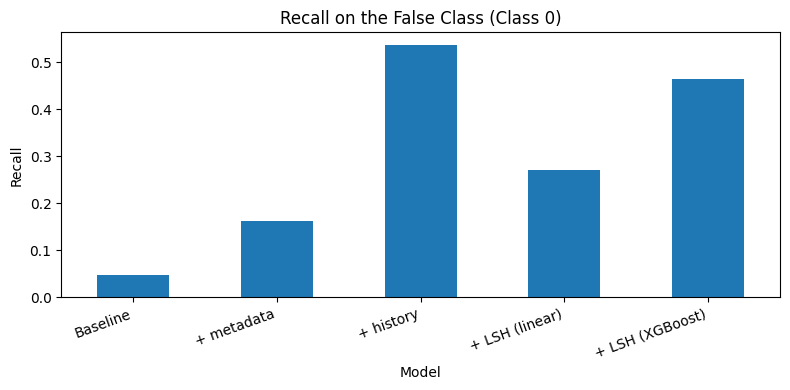

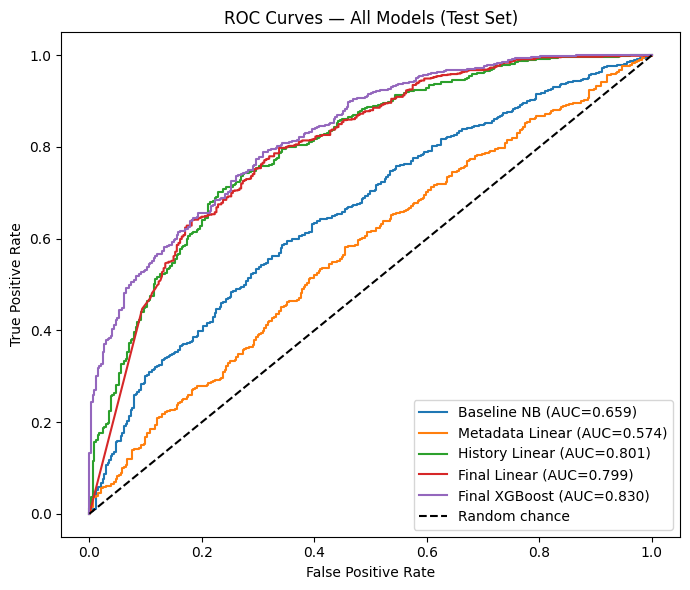

,model,accuracy,macro_f1,false_recall
0,Baseline,0.7301,0.4636,0.0469
1,+ metadata,0.6898,0.5126,0.1613
2,+ history,0.7774,0.7076,0.5367
3,+ LSH (linear),0.7877,0.6385,0.2698
4,+ LSH (XGBoost),0.8027,0.7156,0.4633


In [28]:

# Step 18: Comparative visualizations

class_balance_df = pd.DataFrame({
    "split": ["Train", "Train", "Validation", "Validation", "Test", "Test"],
    "class": ["False (0)", "True (1)", "False (0)", "True (1)", "False (0)", "True (1)"],
    "count": [
        int((y_train == 0).sum()), int((y_train == 1).sum()),
        int((y_valid == 0).sum()), int((y_valid == 1).sum()),
        int((y_test == 0).sum()), int((y_test == 1).sum()),
    ],
})

pivot_balance = class_balance_df.pivot(index="split", columns="class", values="count")
pivot_balance.plot(kind="bar", figsize=(8, 4))
plt.title("Class Distribution Across Dataset Splits")
plt.xlabel("Split")
plt.ylabel("Number of Claims")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

ConfusionMatrixDisplay.from_predictions(y_test, test_pred_nb)
plt.title("Baseline Naive Bayes Confusion Matrix (Test)")
plt.tight_layout()
plt.show()

ConfusionMatrixDisplay.from_predictions(y_test, test_pred_xgb)
plt.title("Final XGBoost Confusion Matrix (Test)")
plt.tight_layout()
plt.show()

plot_metrics_df = pd.DataFrame([
    {"model": "Baseline", "accuracy": baseline_test_metrics["accuracy"], "macro_f1": baseline_test_metrics["macro_f1"], "false_recall": baseline_test_metrics["false_recall"]},
    {"model": "+ metadata", "accuracy": metadata_test_metrics["accuracy"], "macro_f1": metadata_test_metrics["macro_f1"], "false_recall": metadata_test_metrics["false_recall"]},
    {"model": "+ history", "accuracy": history_test_metrics["accuracy"], "macro_f1": history_test_metrics["macro_f1"], "false_recall": history_test_metrics["false_recall"]},
    {"model": "+ LSH (linear)", "accuracy": final_linear_test_metrics["accuracy"], "macro_f1": final_linear_test_metrics["macro_f1"], "false_recall": final_linear_test_metrics["false_recall"]},
    {"model": "+ LSH (XGBoost)", "accuracy": xgb_test_metrics["accuracy"], "macro_f1": xgb_test_metrics["macro_f1"], "false_recall": xgb_test_metrics["false_recall"]},
])

plot_metrics_df.set_index("model")[["accuracy", "macro_f1"]].plot(kind="bar", figsize=(9, 4))
plt.title("Model Comparison on Test Accuracy and Macro-F1")
plt.xlabel("Model")
plt.ylabel("Score")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

plot_metrics_df.set_index("model")[["false_recall"]].plot(kind="bar", figsize=(8, 4), legend=False)
plt.title("Recall on the False Class (Class 0)")
plt.xlabel("Model")
plt.ylabel("Recall")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 6))
for prob, label in [
    (prob_nb, f"Baseline NB (AUC={roc_auc_score(y_test, prob_nb):.3f})"),
    (prob_metadata, f"Metadata Linear (AUC={roc_auc_score(y_test, prob_metadata):.3f})"),
    (prob_history, f"History Linear (AUC={roc_auc_score(y_test, prob_history):.3f})"),
    (prob_final_linear, f"Final Linear (AUC={roc_auc_score(y_test, prob_final_linear):.3f})"),
    (prob_xgb, f"Final XGBoost (AUC={roc_auc_score(y_test, prob_xgb):.3f})"),
]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    ax.plot(fpr, tpr, label=label)

ax.plot([0, 1], [0, 1], "k--", label="Random chance")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — All Models (Test Set)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, "roc_curves_no_graph.png"), dpi=150)
plt.show()

display(plot_metrics_df.round(4))


# 11. Error Analysis

In [20]:

# Step 19: Error analysis utilities

error_analysis_df = test_plus[[
    "statement",
    "statement_clean",
    "speaker",
    "subject",
    "party_affiliation",
    "context",
    "label",
    "y",
]].copy()

error_analysis_df["baseline_pred"] = test_pred_nb
error_analysis_df["final_linear_pred"] = test_pred_final_linear
error_analysis_df["xgb_pred"] = test_pred_xgb

improved_cases = error_analysis_df[
    (error_analysis_df["baseline_pred"] != error_analysis_df["y"]) &
    (error_analysis_df["xgb_pred"] == error_analysis_df["y"])
].copy()

still_wrong_cases = error_analysis_df[
    error_analysis_df["xgb_pred"] != error_analysis_df["y"]
].copy()

print("Examples improved over baseline:", len(improved_cases))
print("Examples still wrong for final XGBoost model:", len(still_wrong_cases))

display(improved_cases.head(10))
display(still_wrong_cases.head(10))


Examples improved over baseline: 164
Examples still wrong for final XGBoost model: 250


,statement,statement_clean,speaker,subject,party_affiliation,context,label,y,baseline_pred,final_linear_pred,xgb_pred
2,Says John McCain has done nothing to help the ...,says john mccain has done nothing to help the ...,donald-trump,OTHER,republican,OTHER,false,0,1,1,0
12,Denali is the Kenyan word for black power.,denali is the kenyan word for black power,viral-image,environment,none,OTHER,pants-fire,0,1,0,0
16,Unfortunately we have documented instances whe...,unfortunately we have documented instances whe...,OTHER,"labor,state-budget",republican,OTHER,pants-fire,0,1,0,0
22,The number of illegal immigrants could be 3 mi...,the number of illegal immigrants could be 3 mi...,donald-trump,immigration,republican,OTHER,pants-fire,0,1,1,0
48,A proposed tax to fund transportation projects...,a proposed tax to fund transportation projects...,OTHER,transportation,republican,OTHER,false,0,1,1,0
54,When undocumented children are picked up at th...,when undocumented children are picked up at th...,OTHER,OTHER,republican,OTHER,false,0,1,0,0
58,ACORN will be a paid partner with the Census B...,acorn will be a paid partner with the census b...,michele-bachmann,census,republican,OTHER,pants-fire,0,1,1,0
59,Sixty percent of the Hispanics support the Ari...,sixty percent of the hispanics support the ari...,OTHER,immigration,republican,a CNN interview,pants-fire,0,1,1,0
80,Rebuilding three high schools will benefit 40 ...,rebuilding three high schools will benefit 40 ...,OTHER,education,none,OTHER,pants-fire,0,1,0,0
95,Says people in Africa literally walk two and t...,says people in africa literally walk two and t...,OTHER,elections,republican,OTHER,pants-fire,0,1,0,0


,statement,statement_clean,speaker,subject,party_affiliation,context,label,y,baseline_pred,final_linear_pred,xgb_pred
1,Wisconsin is on pace to double the number of l...,wisconsin is on pace to double the number of l...,OTHER,jobs,democrat,a news conference,false,0,1,1,1
4,When asked by a reporter whether hes at the ce...,when asked by a reporter whether hes at the ce...,state-democratic-party-wisconsin,OTHER,democrat,a web video,pants-fire,0,0,1,1
13,Says 57 percent of federal spending goes to th...,says 57 percent of federal spending goes to th...,facebook-posts,OTHER,none,a meme on social media,false,0,1,1,1
19,Ronald Reagan faced an even worse recession th...,ronald reagan faced an even worse recession th...,sarah-palin,"economy,history",republican,OTHER,false,0,1,1,1
20,There have not been any public safety issues i...,there have not been any public safety issues i...,OTHER,OTHER,activist,OTHER,mostly-true,1,1,1,0
24,Says Charlie Crist is embroiled in a fraud cas...,says charlie crist is embroiled in a fraud cas...,republican-party-florida,"jobs,state-budget",republican,a TV ad,false,0,0,1,1
30,Its been since 1888 that a Senate of a differe...,its been since 1888 that a senate of a differe...,cory-gardner,OTHER,republican,OTHER,false,0,1,1,1
31,"Under Rosemary Lehmberg, the Travis County D.A...",under rosemary lehmberg the travis county d a ...,sarah-palin,"crime,criminal-justice",republican,a commentary,false,0,1,1,1
33,Tom Ganley has two Fs from the Better Business...,tom ganley has two fs from the better business...,democratic-congressional-campaign-committee,"message-machine,campaign-advertising",democrat,OTHER,half-true,1,1,1,0
36,"Because of the federal health care law, 300,00...",because of the federal health care law 300 000...,rick-scott,health-care,republican,OTHER,barely-true,1,1,1,0


# 12. Exported Outputs

In [ ]:

# Step 20: Save results to CSV 

results_df.to_csv(os.path.join(table_dir, "model_comparison.csv"), index=False)
ablation_df.to_csv(os.path.join(table_dir, "ablation_results.csv"), index=False)
improved_cases.to_csv(os.path.join(table_dir, "improved_cases.csv"), index=False)
still_wrong_cases.to_csv(os.path.join(table_dir, "still_wrong_cases.csv"), index=False)

print("Saved outputs to:", output_dir)
print("Tables saved to:", table_dir)


Saved outputs to: data/liar_project_outputs


## Threshold tuning

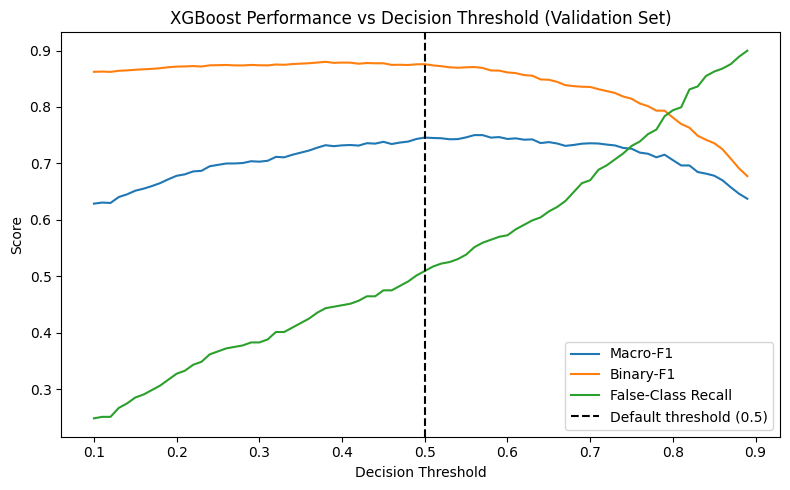

Best threshold by Macro-F1: 0.56
Validation Macro-F1 at best threshold: 0.7502
Validation False-Recall at best threshold: 0.5515
Test (threshold=0.56) Accuracy      : 0.8027
Test (threshold=0.56) Binary-F1     : 0.8705
Test (threshold=0.56) Macro-F1      : 0.7283
Test (threshold=0.56) False Recall  : 0.5191
Test (threshold=0.56) True Recall   : 0.9071
Test (threshold=0.56) AUC-ROC       : 0.8296


,Setting,Threshold,Accuracy,Binary-F1,Macro-F1,False-Recall
0,XGBoost default (t=0.50),0.50,0.8027,0.8730,0.7156,0.4633
1,XGBoost tuned (t=0.56),0.56,0.8027,0.8705,0.7283,0.5191


In [29]:

# Step 21: Threshold tuning on XGBoost using validation set

thresholds = np.arange(0.10, 0.90, 0.01)
results_thresh = []

for t in thresholds:
    preds = (prob_valid_xgb >= t).astype(int)
    macro_f1 = f1_score(y_valid, preds, average="macro", zero_division=0)
    binary_f1 = f1_score(y_valid, preds, average="binary", zero_division=0)
    _, recall, _, _ = precision_recall_fscore_support(
        y_valid, preds, average=None, zero_division=0
    )
    false_recall = recall[0] if len(recall) > 1 else 0.0
    results_thresh.append({
        "threshold": round(t, 2),
        "macro_f1": macro_f1,
        "binary_f1": binary_f1,
        "false_recall": false_recall,
    })

thresh_df = pd.DataFrame(results_thresh)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(thresh_df["threshold"], thresh_df["macro_f1"], label="Macro-F1")
ax.plot(thresh_df["threshold"], thresh_df["binary_f1"], label="Binary-F1")
ax.plot(thresh_df["threshold"], thresh_df["false_recall"], label="False-Class Recall")
ax.axvline(x=0.5, color="k", linestyle="--", label="Default threshold (0.5)")
ax.set_xlabel("Decision Threshold")
ax.set_ylabel("Score")
ax.set_title("XGBoost Performance vs Decision Threshold (Validation Set)")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, "threshold_tuning_no_graph.png"), dpi=150)
plt.show()

best_row = thresh_df.loc[thresh_df["macro_f1"].idxmax()]
best_threshold = float(best_row["threshold"])
print(f"Best threshold by Macro-F1: {best_threshold:.2f}")
print(f"Validation Macro-F1 at best threshold: {best_row['macro_f1']:.4f}")
print(f"Validation False-Recall at best threshold: {best_row['false_recall']:.4f}")

test_pred_xgb_tuned = (prob_xgb >= best_threshold).astype(int)
tuned_test_metrics = evaluate_predictions(y_test, test_pred_xgb_tuned, prob_xgb, f"Test (threshold={best_threshold:.2f})")

comparison_thresh = pd.DataFrame([
    {
        "Setting": "XGBoost default (t=0.50)",
        "Threshold": 0.50,
        "Accuracy": round(xgb_test_metrics["accuracy"], 4),
        "Binary-F1": round(xgb_test_metrics["binary_f1"], 4),
        "Macro-F1": round(xgb_test_metrics["macro_f1"], 4),
        "False-Recall": round(xgb_test_metrics["false_recall"], 4),
    },
    {
        "Setting": f"XGBoost tuned (t={best_threshold:.2f})",
        "Threshold": best_threshold,
        "Accuracy": round(tuned_test_metrics["accuracy"], 4),
        "Binary-F1": round(tuned_test_metrics["binary_f1"], 4),
        "Macro-F1": round(tuned_test_metrics["macro_f1"], 4),
        "False-Recall": round(tuned_test_metrics["false_recall"], 4),
    },
])

display(comparison_thresh)


# 13. Conclusions, limitations, and next steps

## Main takeaways

From the consolidated results and ablation study, several conclusions emerge:

- The project goes meaningfully beyond a text-only baseline.
- **Speaker-history features** appear especially important; removing them causes one of the largest drops in performance.
- **LSH-based similar-claim retrieval features** also provide useful gains, especially when combined with the other engineered features.
- The final **XGBoost** model achieves the strongest overall performance in the current notebook, while threshold tuning slightly improves the balance between classes.
